# Fine-tuned TrOCR test samples

This notebook selects 20 deterministic random samples from each language's held-out `gt_test.txt` split. For every sample it displays the original line image, then prints the image filename, reference transcription, model prediction, and character error rate (CER).

It uses each run's validation-selected `best` model weights. The matching `final` export supplies the image-processor configuration because that file is not present in `best`.

Run the notebook from the repository environment, for example with `uv run --extra train --group parity jupyter lab`.

In [20]:
from __future__ import annotations

from html import escape
from pathlib import Path
from random import Random

import torch
from IPython.display import HTML, display
from PIL import Image
from transformers import TrOCRProcessor

from pathlib import Path
import sys

for project_root in (Path.cwd(), *Path.cwd().parents):
    if (project_root / "pyproject.toml").is_file() and (project_root / "src").is_dir():
        sys.path.insert(0, str(project_root))
        break
else:
    raise RuntimeError("Could not find the Greek OCR project root.")


from src.metrics.metrics import edit_distance
from src.models.trocr.dataloader import read_ground_truth
from src.models.trocr.model_builder import load_model


def repository_root(start: Path) -> Path:
    for directory in (start, *start.parents):
        if (directory / "pyproject.toml").is_file():
            return directory
    raise FileNotFoundError("Could not find the repository root from the current directory.")


REPO_ROOT = repository_root(Path.cwd())
SAMPLE_COUNT = 40
RANDOM_SEED = 1111
MAX_LENGTH = 60
NUM_BEAMS = 1

# `best` contains the checkpoint selected by minimum validation CER. It lacks
# `preprocessor_config.json`, so load its matching processor from `final`.
LANGUAGES = {
    "Armenian": {
        "data_dir": REPO_ROOT / "data/processed/armenian/finetuning",
        "model_checkpoint": REPO_ROOT / (
            "checkpoints/tr_ocr/finetuned/from_armenian/"
            "trocr-finetuning-armenian-qd7x461y--20260822T180943191868Z--slurm-39552/best"
        ),
        "processor_checkpoint": REPO_ROOT / (
            "checkpoints/tr_ocr/finetuned/from_armenian/"
            "trocr-finetuning-armenian-qd7x461y--20260822T180943191868Z--slurm-39552/final"
        ),
    },
    "Greek": {
        "data_dir": REPO_ROOT / "data/processed/greek/finetuning",
        "model_checkpoint": REPO_ROOT / (
            "checkpoints/tr_ocr/finetuned/from_greek/"
            "trocr-finetuning-greek-15cdts6r--20260822T184710795560Z--slurm-39553/best"
        ),
        "processor_checkpoint": REPO_ROOT / (
            "checkpoints/tr_ocr/finetuned/from_greek/"
            "trocr-finetuning-greek-15cdts6r--20260822T184710795560Z--slurm-39553/final"
        ),
    },
    "Syriac": {
        "data_dir": REPO_ROOT / "data/processed/syriac/finetuning",
        "model_checkpoint": REPO_ROOT / (
            "checkpoints/tr_ocr/finetuned/from_syraic/"
            "trocr-finetuning-syriac-2s92ih3g--20260822T190341663503Z--slurm-39554/best"
        ),
        "processor_checkpoint": REPO_ROOT / (
            "checkpoints/tr_ocr/finetuned/from_syraic/"
            "trocr-finetuning-syriac-2s92ih3g--20260822T190341663503Z--slurm-39554/final"
        ),
    },
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Repository: {REPO_ROOT}")
print(f"Device: {DEVICE}")

Repository: /home/math/gupta/work/greek_byzantine/greek-foundation
Device: cuda


In [21]:
def sample_test_set(
    language: str,
    *,
    data_dir: Path,
    model_checkpoint: Path,
    processor_checkpoint: Path,
    sample_count: int,
    seed: int,
) -> list[dict[str, object]]:
    """Generate predictions and per-sample CER for random test-set rows."""
    manifest = data_dir / "gt_test.txt"
    if not manifest.is_file():
        raise FileNotFoundError(f"{language}: test manifest not found: {manifest}")
    if not model_checkpoint.is_dir():
        raise FileNotFoundError(f"{language}: model checkpoint not found: {model_checkpoint}")
    if not processor_checkpoint.is_dir():
        raise FileNotFoundError(
            f"{language}: processor checkpoint not found: {processor_checkpoint}"
        )

    samples = read_ground_truth(manifest)
    selected = Random(seed).sample(samples, k=min(sample_count, len(samples)))
    if len(selected) < sample_count:
        print(f"{language}: only {len(selected)} test samples are available.")

    processor = TrOCRProcessor.from_pretrained(processor_checkpoint)
    model = load_model(str(model_checkpoint)).to(DEVICE).eval()
    results = []
    with torch.inference_mode():
        for image_name, reference in selected:
            with Image.open(data_dir / "image" / image_name) as image:
                pixel_values = processor(
                    images=image.convert("RGB"), return_tensors="pt"
                ).pixel_values.to(DEVICE)
            generated_ids = model.generate(
                pixel_values, max_length=MAX_LENGTH, num_beams=NUM_BEAMS
            )
            prediction = processor.batch_decode(
                generated_ids,
                skip_special_tokens=True,
                clean_up_tokenization_spaces=False,
            )[0]
            edits = edit_distance(reference, prediction)
            cer = edits / len(reference) if reference else float(bool(prediction))
            results.append(
                {
                    "image_name": image_name,
                    "image_path": data_dir / "image" / image_name,
                    "reference": reference,
                    "prediction": prediction,
                    "edits": edits,
                    "reference_characters": len(reference),
                    "cer": cer,
                }
            )
    return results


def character_alignment(reference: str, prediction: str) -> list[tuple[str, str, str]]:
    """Align two transcriptions as equal, replacement, insertion, or deletion edits."""
    scores = [[0] * (len(prediction) + 1) for _ in range(len(reference) + 1)]
    for reference_index in range(len(reference) + 1):
        scores[reference_index][0] = reference_index
    for prediction_index in range(len(prediction) + 1):
        scores[0][prediction_index] = prediction_index

    for reference_index, reference_character in enumerate(reference, start=1):
        for prediction_index, prediction_character in enumerate(prediction, start=1):
            substitution_cost = int(reference_character != prediction_character)
            scores[reference_index][prediction_index] = min(
                scores[reference_index - 1][prediction_index] + 1,
                scores[reference_index][prediction_index - 1] + 1,
                scores[reference_index - 1][prediction_index - 1] + substitution_cost,
            )

    alignment = []
    reference_index = len(reference)
    prediction_index = len(prediction)
    while reference_index or prediction_index:
        if (
            reference_index
            and prediction_index
            and reference[reference_index - 1] == prediction[prediction_index - 1]
            and scores[reference_index][prediction_index]
            == scores[reference_index - 1][prediction_index - 1]
        ):
            alignment.append(("equal", reference[reference_index - 1], prediction[prediction_index - 1]))
            reference_index -= 1
            prediction_index -= 1
        elif (
            reference_index
            and prediction_index
            and scores[reference_index][prediction_index]
            == scores[reference_index - 1][prediction_index - 1] + 1
        ):
            alignment.append(("replace", reference[reference_index - 1], prediction[prediction_index - 1]))
            reference_index -= 1
            prediction_index -= 1
        elif reference_index and scores[reference_index][prediction_index] == scores[reference_index - 1][prediction_index] + 1:
            alignment.append(("delete", reference[reference_index - 1], "∅"))
            reference_index -= 1
        else:
            alignment.append(("insert", "∅", prediction[prediction_index - 1]))
            prediction_index -= 1
    return list(reversed(alignment))


def highlighted_transcription_comparison(reference: str, prediction: str) -> HTML:
    """Render an aligned reference/prediction pair with edit characters highlighted."""
    reference_parts = []
    prediction_parts = []
    for operation, reference_character, prediction_character in character_alignment(reference, prediction):
        if operation == "equal":
            reference_parts.append(escape(reference_character))
            prediction_parts.append(escape(prediction_character))
        else:
            reference_parts.append(f'<mark>{escape(reference_character)}</mark>')
            prediction_parts.append(f'<mark>{escape(prediction_character)}</mark>')

    return HTML(
        "<div style='font-family: monospace; white-space: pre-wrap'>"
        f"<strong>reference:</strong>  {''.join(reference_parts)}<br>"
        f"<strong>prediction:</strong> {''.join(prediction_parts)}"
        "</div>"
    )

In [22]:
results_by_language = {}
for language_index, (language, paths) in enumerate(LANGUAGES.items()):
    print(f"Evaluating {language}...")
    results_by_language[language] = sample_test_set(
        language,
        data_dir=paths["data_dir"],
        model_checkpoint=paths["model_checkpoint"],
        processor_checkpoint=paths["processor_checkpoint"],
        sample_count=SAMPLE_COUNT,
        seed=RANDOM_SEED + language_index,
    )

Evaluating Armenian...


Loading weights: 100%|██████████| 479/479 [00:00<00:00, 19096.01it/s]


Evaluating Greek...
Greek: only 11 test samples are available.


Loading weights: 100%|██████████| 479/479 [00:00<00:00, 15153.43it/s]


Evaluating Syriac...


Loading weights: 100%|██████████| 479/479 [00:00<00:00, 20484.64it/s]



Armenian — 40 random test samples

[01] ms_p_331_ff24r_34r__0007_27r__006.jpg


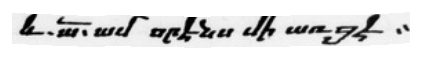

  CER: 0.0435 (1/23 edits)

[02] ms_p_172_canonsdvin719_partaw768_dvin644_karin_complete__0016_p016__031.jpg


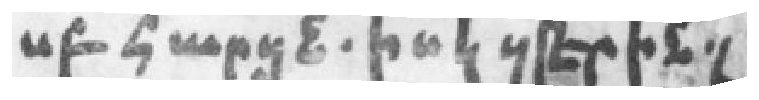

  CER: 0.1905 (4/21 edits)

[03] ms_ucla_ms_72_ff64v_73v__0003_65v__021.jpg


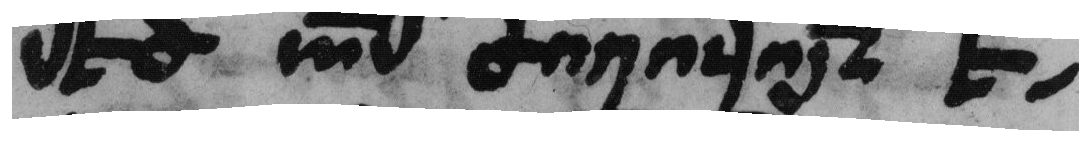

  CER: 0.0556 (1/18 edits)

[04] ms_p_172_canonsdvin719_partaw768_dvin644_karin_complete__0011_p011__024.jpg


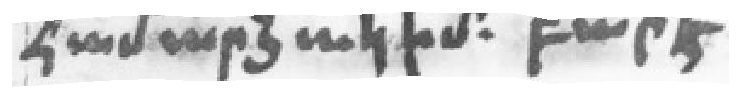

  CER: 0.0000 (0/16 edits)

[05] ms_p_172_canonsdvin719_partaw768_dvin644_karin_complete__0016_p016__008.jpg


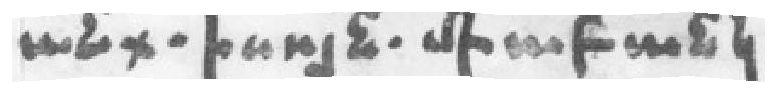

  CER: 0.1176 (2/17 edits)

[06] ms_p_331_ff24r_34r__0007_27r__012.jpg


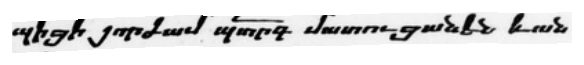

  CER: 0.0323 (1/31 edits)

[07] ms_p_172_canonsdvin719_partaw768_dvin644_karin_complete__0002_p002__043.jpg


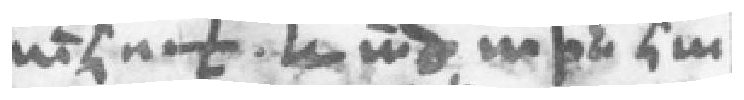

  CER: 0.1333 (2/15 edits)

[08] ms_ucla_ms_72_ff64v_73v__0003_65v__029.jpg


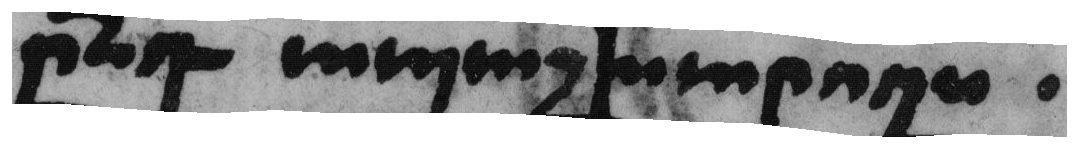

  CER: 0.0000 (0/15 edits)

[09] ms_p_331_ff24r_34r__0011_29r__014.jpg


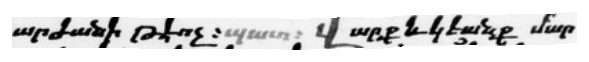

  CER: 0.0938 (3/32 edits)

[10] ms_p_172_canonsdvin719_partaw768_dvin644_karin_complete__0004_p004__035.jpg


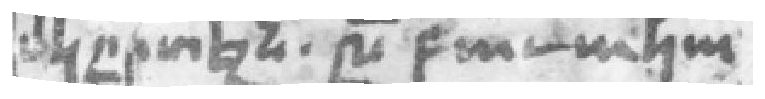

  CER: 0.2778 (5/18 edits)

[11] ms_ucla_ms_72_ff64v_73v__0013_70v__030.jpg


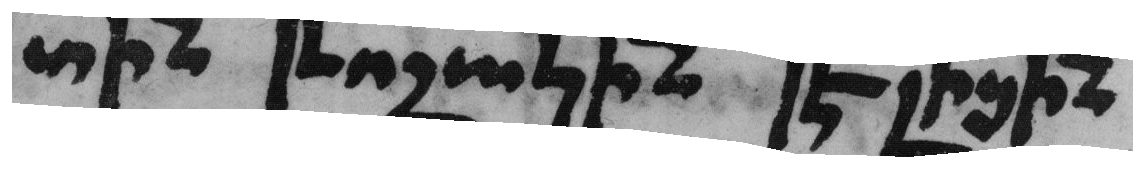

  CER: 0.0952 (2/21 edits)

[12] ms_p_331_ff24r_34r__0013_30r__003.jpg


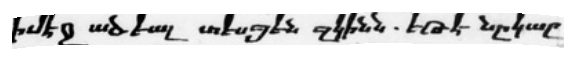

  CER: 0.0882 (3/34 edits)

[13] ms_p_172_canonsdvin719_partaw768_dvin644_karin_complete__0016_p016__005.jpg


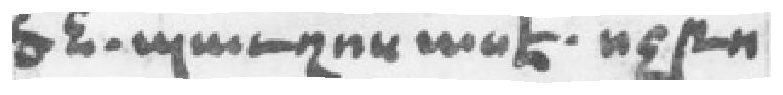

  CER: 0.4118 (7/17 edits)

[14] ms_p_331_ff24r_34r__0018_32v__024.jpg


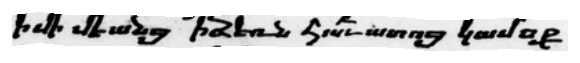

  CER: 0.0000 (0/29 edits)

[15] ms_ucla_ms_72_ff64v_73v__0003_65v__014.jpg


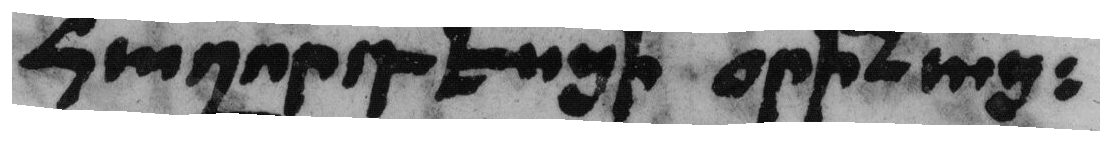

  CER: 0.0000 (0/18 edits)

[16] ms_p_172_canonsdvin719_partaw768_dvin644_karin_complete__0002_p002__057.jpg


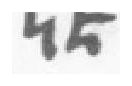

  CER: 0.0000 (0/2 edits)

[17] ms_ucla_ms_72_ff64v_73v__0013_70v__034.jpg


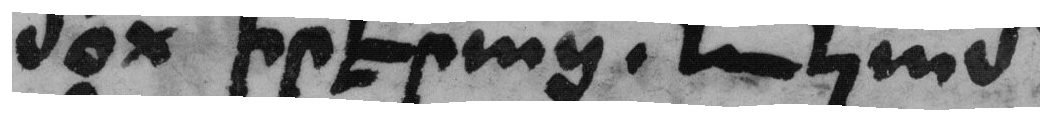

  CER: 0.0000 (0/16 edits)

[18] ms_p_172_canonsdvin719_partaw768_dvin644_karin_complete__0004_p004__028.jpg


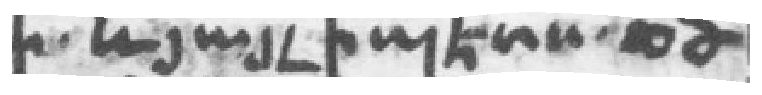

  CER: 0.1765 (3/17 edits)

[19] ms_p_331_ff24r_34r__0013_30r__011.jpg


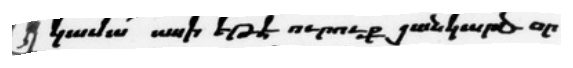

  CER: 0.1562 (5/32 edits)

[20] ms_p_331_ff24r_34r__0012_29v__017.jpg


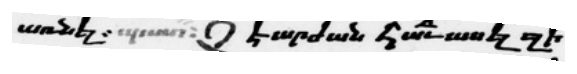

  CER: 0.0645 (2/31 edits)

[21] ms_ucla_ms_72_ff64v_73v__0010_69r__022.jpg


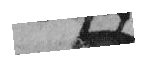

  CER: 0.6667 (2/3 edits)

[22] ms_p_172_canonsdvin719_partaw768_dvin644_karin_complete__0011_p011__020.jpg


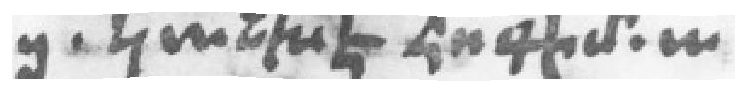

  CER: 0.0000 (0/17 edits)

[23] ms_p_172_canonsdvin719_partaw768_dvin644_karin_complete__0001_p001__035.jpg


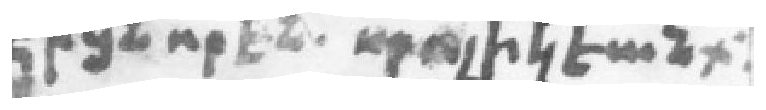

  CER: 0.2500 (5/20 edits)

[24] ms_ucla_ms_72_ff64v_73v__0013_70v__039.jpg


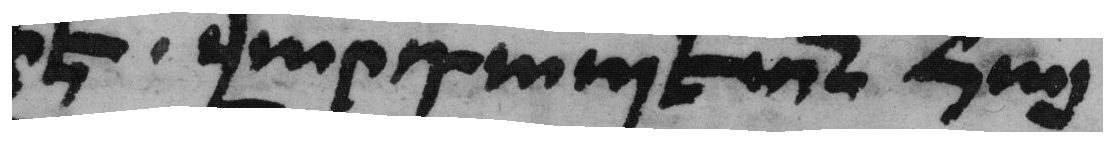

  CER: 0.0556 (1/18 edits)

[25] ms_p_331_ff24r_34r__0007_27r__031.jpg


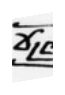

  CER: 0.0000 (0/3 edits)

[26] ms_ucla_ms_72_ff64v_73v__0013_70v__041.jpg


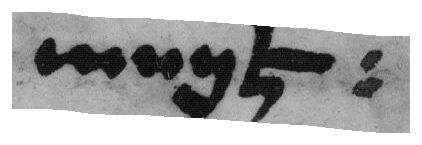

  CER: 0.0000 (0/5 edits)

[27] ms_p_172_canonsdvin719_partaw768_dvin644_karin_complete__0016_p016__006.jpg


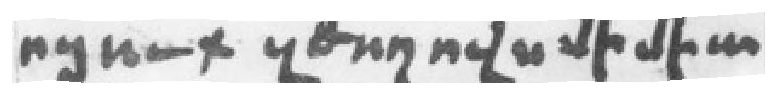

  CER: 0.2222 (4/18 edits)

[28] ms_p_172_canonsdvin719_partaw768_dvin644_karin_complete__0011_p011__035.jpg


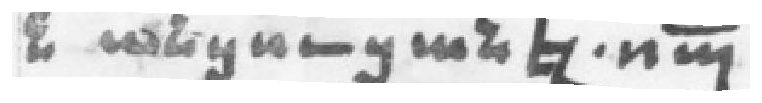

  CER: 0.0000 (0/16 edits)

[29] ms_p_172_canonsdvin719_partaw768_dvin644_karin_complete__0004_p004__046.jpg


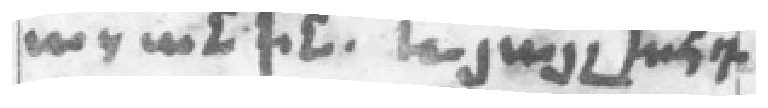

  CER: 0.0625 (1/16 edits)

[30] ms_p_172_canonsdvin719_partaw768_dvin644_karin_complete__0004_p004__018.jpg


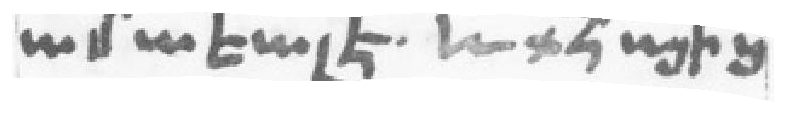

  CER: 0.1250 (2/16 edits)

[31] ms_p_331_ff24r_34r__0012_29v__004.jpg


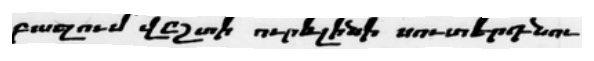

  CER: 0.0938 (3/32 edits)

[32] ms_p_331_ff24r_34r__0007_27r__026.jpg


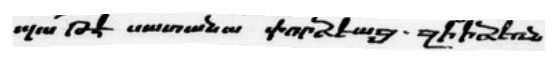

  CER: 0.1613 (5/31 edits)

[33] ms_ucla_ms_72_ff64v_73v__0003_65v__041.jpg


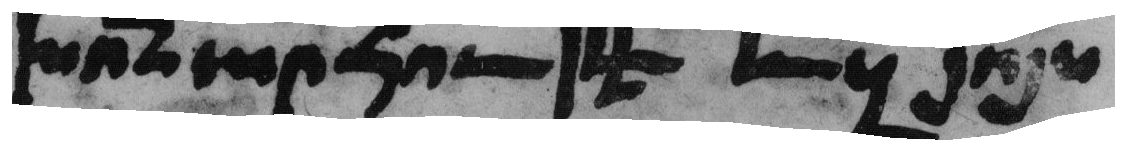

  CER: 0.0000 (0/17 edits)

[34] ms_ucla_ms_72_ff64v_73v__0014_71r__040.jpg


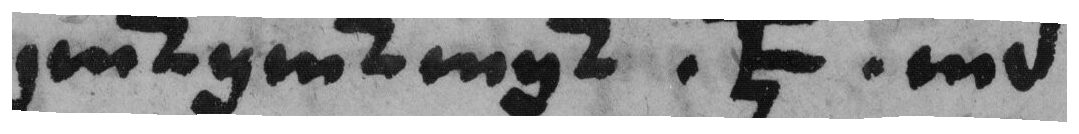

  CER: 0.0000 (0/16 edits)

[35] ms_p_172_canonsdvin719_partaw768_dvin644_karin_complete__0004_p004__012.jpg


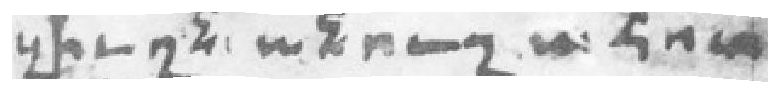

  CER: 0.1250 (2/16 edits)

[36] ms_ucla_ms_72_ff64v_73v__0005_66v__021.jpg


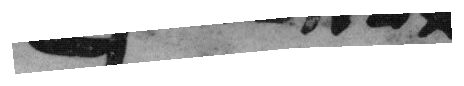

  CER: 0.4286 (3/7 edits)

[37] ms_p_331_ff24r_34r__0013_30r__009.jpg


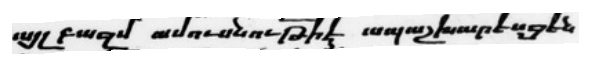

  CER: 0.0938 (3/32 edits)

[38] ms_p_172_canonsdvin719_partaw768_dvin644_karin_complete__0002_p002__033.jpg


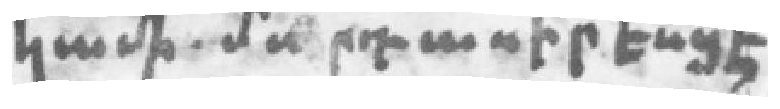

  CER: 0.1111 (2/18 edits)

[39] ms_p_172_canonsdvin719_partaw768_dvin644_karin_complete__0001_p001__011.jpg


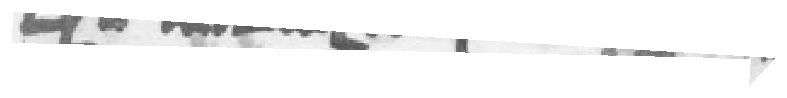

  CER: 0.7500 (12/16 edits)

[40] ms_p_172_canonsdvin719_partaw768_dvin644_karin_complete__0004_p004__056.jpg


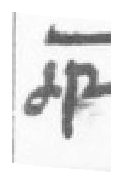

  CER: 0.5000 (1/2 edits)

Corpus CER for these samples: 0.1173 (11.73%)

Greek — 11 random test samples

[01] Grec_1360_CONSTANTINUS_Harmenopulus_btv1b10721710m_7_29.jpg


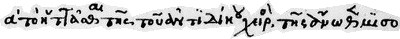

  CER: 0.5818 (32/55 edits)

[02] Grec_1360_CONSTANTINUS_Harmenopulus_btv1b10721710m_6_5.jpg


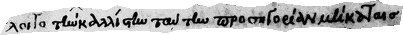

  CER: 0.2500 (12/48 edits)

[03] Grec_1360_CONSTANTINUS_Harmenopulus_btv1b10721710m_8_30.jpg


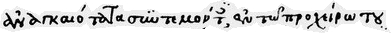

  CER: 0.4000 (18/45 edits)

[04] Grec_1360_CONSTANTINUS_Harmenopulus_btv1b10721710m_6_19.jpg


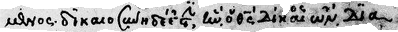

  CER: 0.6889 (31/45 edits)

[05] Grec_1360_CONSTANTINUS_Harmenopulus_btv1b10721710m_7_13.jpg


  CER: 0.4667 (28/60 edits)

[06] Grec_1360_CONSTANTINUS_Harmenopulus_btv1b10721710m_7_47.jpg


  CER: 0.3529 (18/51 edits)

[07] Grec_1360_CONSTANTINUS_Harmenopulus_btv1b10721710m_8_17.jpg


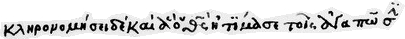

  CER: 0.3617 (17/47 edits)

[08] Grec_1360_CONSTANTINUS_Harmenopulus_btv1b10721710m_7_11.jpg


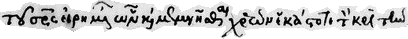

  CER: 0.6462 (42/65 edits)

[09] Grec_1360_CONSTANTINUS_Harmenopulus_btv1b10721710m_7_30.jpg


  CER: 0.3061 (15/49 edits)

[10] Grec_1360_CONSTANTINUS_Harmenopulus_btv1b10721710m_8_27.jpg


  CER: 0.4000 (18/45 edits)

[11] Grec_1360_CONSTANTINUS_Harmenopulus_btv1b10721710m_7_40.jpg


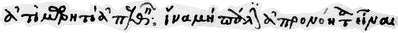

  CER: 0.4681 (22/47 edits)

Corpus CER for these samples: 0.4542 (45.42%)

Syriac — 40 random test samples

[01] syriac_2025_coordinates_0002361.jpg


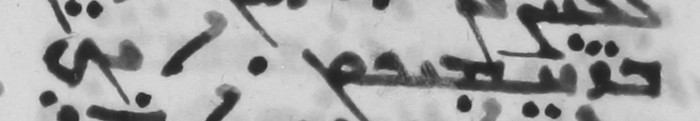

  CER: 0.0000 (0/14 edits)

[02] syriac_2025_coordinates_0002378.jpg


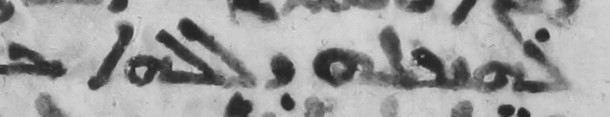

  CER: 0.0667 (1/15 edits)

[03] syriac_2025_coordinates_0002451.jpg


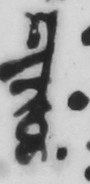

  CER: 0.6000 (3/5 edits)

[04] syriac_2025_coordinates_0002382.jpg


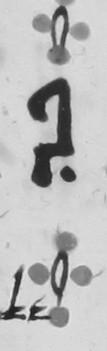

  CER: 0.7500 (3/4 edits)

[05] syriac_2025_coordinates_0002406.jpg


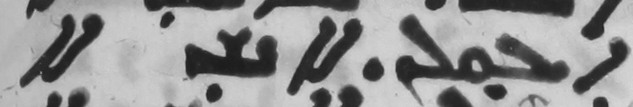

  CER: 0.0000 (0/14 edits)

[06] syriac_2025_coordinates_0002356.jpg


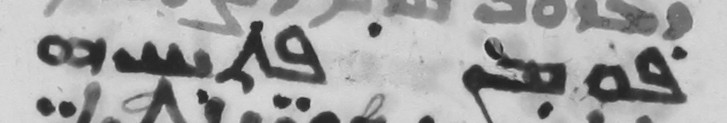

  CER: 0.2500 (3/12 edits)

[07] syriac_2025_coordinates_0002429.jpg


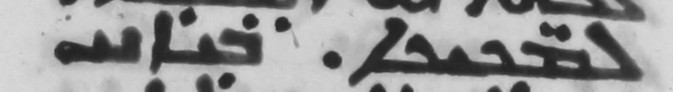

  CER: 0.0000 (0/13 edits)

[08] syriac_2025_coordinates_0002405.jpg


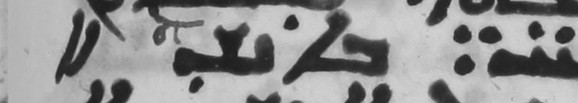

  CER: 0.1538 (2/13 edits)

[09] syriac_2025_coordinates_0002619.jpg


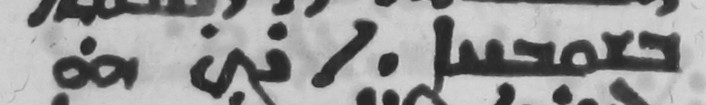

  CER: 0.0000 (0/15 edits)

[10] syriac_2025_coordinates_0002606.jpg


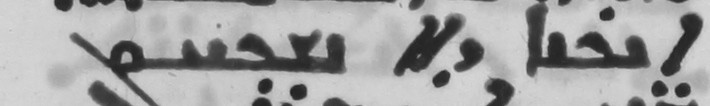

  CER: 0.0000 (0/16 edits)

[11] syriac_2025_coordinates_0002389.jpg


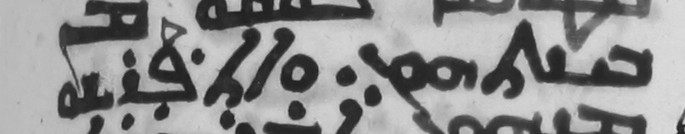

  CER: 0.0625 (1/16 edits)

[12] syriac_2025_coordinates_0002556.jpg


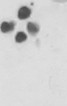

  CER: 0.0000 (0/1 edits)

[13] syriac_2025_coordinates_0002371.jpg


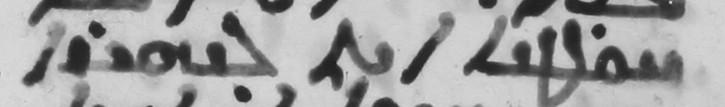

  CER: 0.0000 (0/17 edits)

[14] syriac_2025_coordinates_0002398.jpg


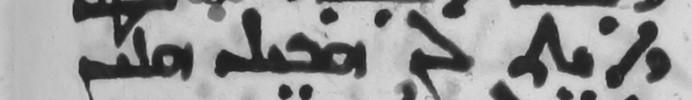

  CER: 0.0000 (0/17 edits)

[15] syriac_2025_coordinates_0002379.jpg


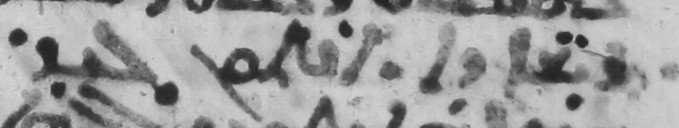

  CER: 0.0588 (1/17 edits)

[16] syriac_2025_coordinates_0002391.jpg


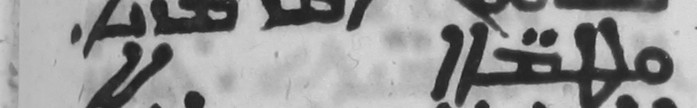

  CER: 0.1000 (1/10 edits)

[17] syriac_2025_coordinates_0002403.jpg


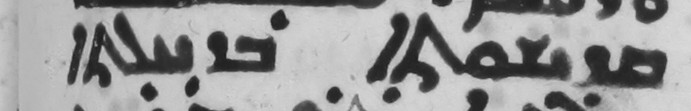

  CER: 0.0000 (0/14 edits)

[18] syriac_2025_coordinates_0002482.jpg


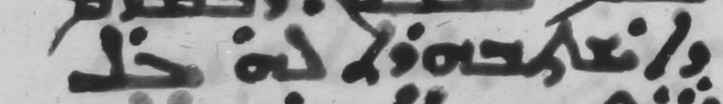

  CER: 0.0714 (1/14 edits)

[19] syriac_2025_coordinates_0002413.jpg


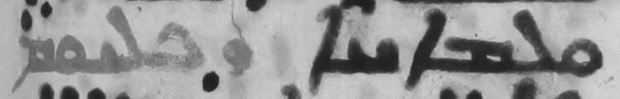

  CER: 0.2308 (3/13 edits)

[20] syriac_2025_coordinates_0002483.jpg


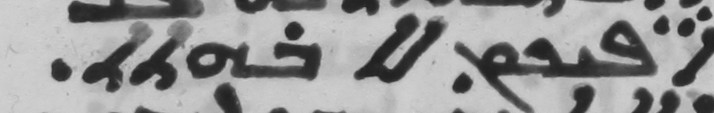

  CER: 0.1333 (2/15 edits)

[21] syriac_2025_coordinates_0002442.jpg


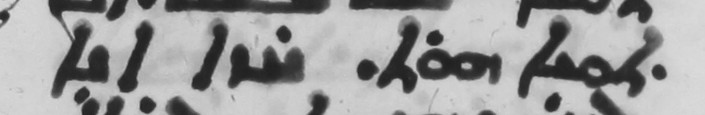

  CER: 0.0588 (1/17 edits)

[22] syriac_2025_coordinates_0002523.jpg


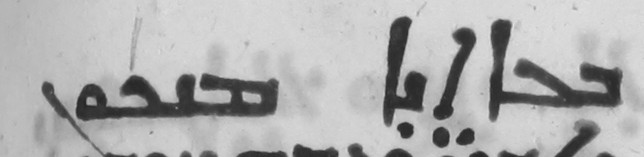

  CER: 0.0000 (0/13 edits)

[23] syriac_2025_coordinates_0002510.jpg


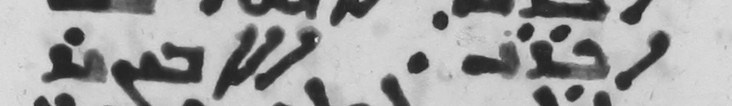

  CER: 0.0769 (1/13 edits)

[24] syriac_2025_coordinates_0002517.jpg


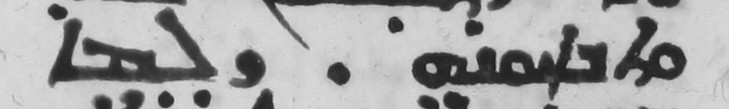

  CER: 0.1538 (2/13 edits)

[25] syriac_2025_coordinates_0002493.jpg


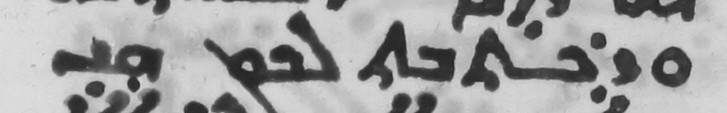

  CER: 0.0714 (1/14 edits)

[26] syriac_2025_coordinates_0002416.jpg


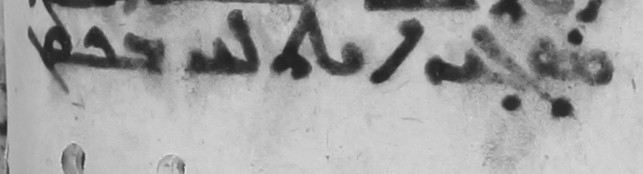

  CER: 0.2000 (3/15 edits)

[27] syriac_2025_coordinates_0002369.jpg


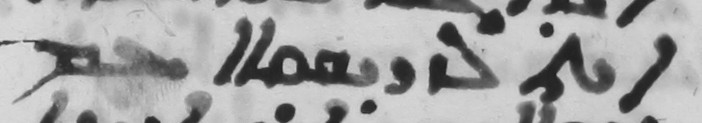

  CER: 0.0000 (0/15 edits)

[28] syriac_2025_coordinates_0002534.jpg


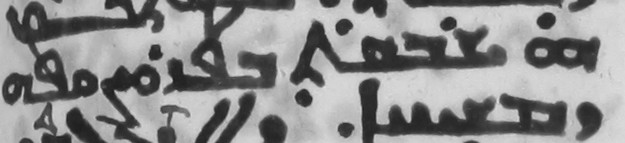

  CER: 0.0588 (1/17 edits)

[29] syriac_2025_coordinates_0002354.jpg


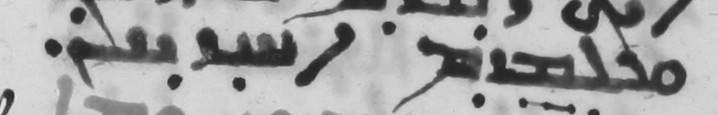

  CER: 0.0667 (1/15 edits)

[30] syriac_2025_coordinates_0002423.jpg


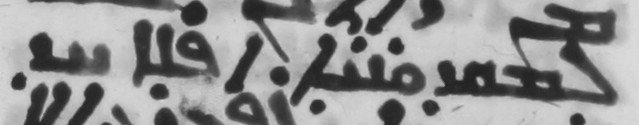

  CER: 0.0000 (0/17 edits)

[31] syriac_2025_coordinates_0002350.jpg


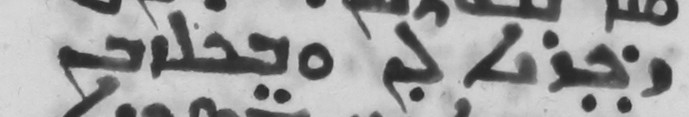

  CER: 0.0000 (0/16 edits)

[32] syriac_2025_coordinates_0002473.jpg


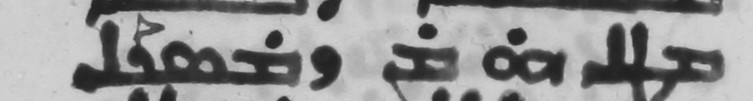

  CER: 0.0588 (1/17 edits)

[33] syriac_2025_coordinates_0002585.jpg


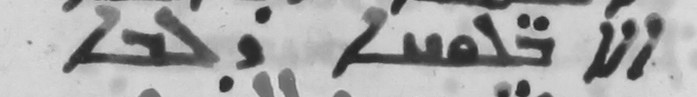

  CER: 0.0000 (0/15 edits)

[34] syriac_2025_coordinates_0002520.jpg


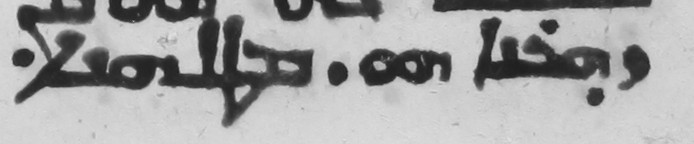

  CER: 0.0625 (1/16 edits)

[35] syriac_2025_coordinates_0002535.jpg


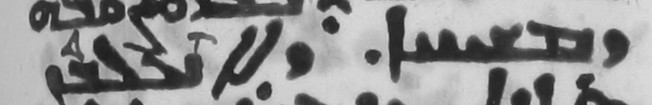

  CER: 0.0625 (1/16 edits)

[36] syriac_2025_coordinates_0002551.jpg


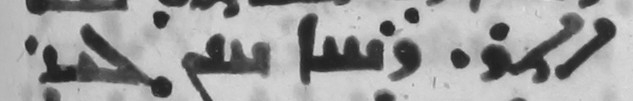

  CER: 0.0588 (1/17 edits)

[37] syriac_2025_coordinates_0002385.jpg


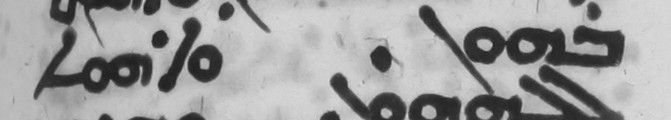

  CER: 0.0000 (0/11 edits)

[38] syriac_2025_coordinates_0002464.jpg


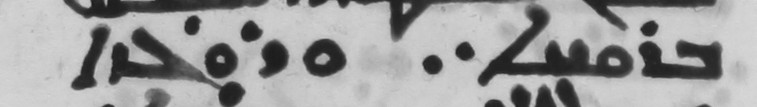

  CER: 0.0000 (0/13 edits)

[39] syriac_2025_coordinates_0002565.jpg


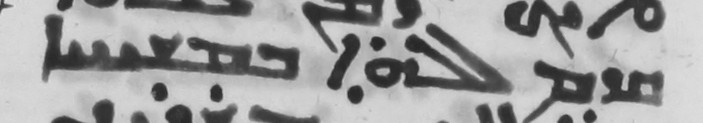

  CER: 0.0000 (0/15 edits)

[40] syriac_2025_coordinates_0002496.jpg


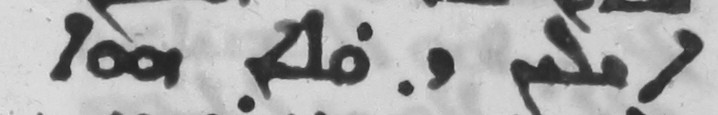

  CER: 0.0000 (0/14 edits)

Corpus CER for these samples: 0.0632 (6.32%)


In [23]:
for language, results in results_by_language.items():
    total_edits = sum(row["edits"] for row in results)
    total_characters = sum(row["reference_characters"] for row in results)
    corpus_cer = total_edits / total_characters if total_characters else 0.0

    print(f"\n{'=' * 80}\n{language} — {len(results)} random test samples")
    for index, row in enumerate(results, start=1):
        print(f"\n[{index:02d}] {row['image_name']}")
        with Image.open(row["image_path"]) as image:
            display(image.copy())
        display(highlighted_transcription_comparison(row["reference"], row["prediction"]))
        print(f"  CER: {row['cer']:.4f} ({row['edits']}/{row['reference_characters']} edits)")

    print(f"\nCorpus CER for these samples: {corpus_cer:.4f} ({corpus_cer * 100:.2f}%)")